In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns




In [4]:
df = pd.read_csv('../data/raw/financial_fraud_detection_dataset.csv')



(5000000, 18)

In [ ]:
df.shape

The dataset contains **5 million financial transactions**.  

If there are just a few rows with missing values, they can be safely dropped without significantly affecting the overall data distribution.

In [4]:
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [5]:
df.tail()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
4999995,T5099995,2023-11-17T23:20:29.746144,ACC597319,ACC749300,10.87,withdrawal,retail,Toronto,atm,False,NaN,1416.524233,-0.14,17,0.18,UPI,243.92.38.163,D4439579
4999996,T5099996,2023-09-23T11:23:20.659686,ACC749625,ACC709783,181.40,payment,grocery,Sydney,atm,False,NaN,999.089702,-1.79,4,0.58,wire_transfer,28.252.18.249,D5029311
4999997,T5099997,2023-11-18T00:52:34.527092,ACC629492,ACC680736,12.54,payment,utilities,New York,mobile,False,NaN,3871.584025,-0.30,6,0.99,card,111.199.174.121,D6333607
4999998,T5099998,2023-03-25T04:32:13.609837,ACC984720,ACC296935,376.29,deposit,restaurant,Dubai,pos,False,NaN,-4096.765453,-1.43,5,0.32,wire_transfer,221.110.215.14,D1551203
4999999,T5099999,2023-09-02T04:34:34.583803,ACC120255,ACC440137,7.27,transfer,grocery,Sydney,atm,False,NaN,5257.349021,0.08,14,0.40,wire_transfer,246.68.126.184,D1505627


The dataset is NOT sorted by the `timestamp` column. 
Evidence: In df.head(), the second row (2023-08-04) is earlier than the first row (2023-08-22). 
In df.tail(), timestamps jump around (2023-11-17, 2023-09-23, 2023-11-18, 2023-03-25, 2023-09-02). 
It appears the data is sorted only by `transaction_id`.

In [6]:
df.sample(5)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
2701378,T2801378,2023-01-06T02:26:05.196628,ACC217840,ACC212809,28.89,transfer,entertainment,Tokyo,web,True,card_not_present,-8601.984355,-0.36,15,0.62,wire_transfer,144.117.152.103,D8008039
3088014,T3188014,2023-05-15T16:33:36.806305,ACC273248,ACC535460,213.95,payment,restaurant,Singapore,atm,False,NaN,467.645625,-0.33,19,0.61,wire_transfer,234.65.139.247,D5944929
3202992,T3302992,2023-09-01T21:28:33.308040,ACC968983,ACC764522,25.06,payment,entertainment,Berlin,web,False,NaN,NaN,-0.30,4,0.82,ACH,20.229.25.161,D9485885
2856218,T2956218,2023-09-19T19:09:54.326149,ACC858715,ACC122120,157.52,payment,travel,Tokyo,mobile,False,NaN,5224.695564,1.00,16,1.00,ACH,202.8.236.242,D9559063
499817,T599817,2023-10-30T01:45:37.128195,ACC492803,ACC937721,374.11,withdrawal,entertainment,Singapore,atm,False,NaN,NaN,-0.66,19,0.03,UPI,187.240.190.250,D2891445


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               str    
 1   timestamp                    str    
 2   sender_account               str    
 3   receiver_account             str    
 4   amount                       float64
 5   transaction_type             str    
 6   merchant_category            str    
 7   location                     str    
 8   device_used                  str    
 9   is_fraud                     bool   
 10  fraud_type                   str    
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              str    
 16  ip_address                   str    
 17  device_hash                  str    
dtypes: bool(1), float64(4), int64(1), str(12)
memory usag

## Feature Selection and Target Variable

We use **`is_fraud`** as the target variable, as our goal is to predict whether a transaction is fraudulent.  

We remove the columns **`transaction_id`** and **`fraud_type`** from the model: the former serves only as an identifier, and including the latter would introduce data leakage.  

The behavioral and statistical features — **`amount`**, **`time_since_last_transaction`**, **`spending_deviation_score`**, **`velocity_score`**, and **`geo_anomaly_score`** — are likely highly informative for detecting fraudulent transactions.  

Contextual transaction features — **`transaction_type`**, **`merchant_category`**, **`payment_channel`**, and **`device_used`** — are also predictive, but must be encoded as categorical variables (e.g., using one-hot encoding or ordinal encoding) before being used by the model.  

Other columns — **`timestamp`**, **`location`**, **`sender_account`**, **`receiver_account`**, **`ip_address`**, and **`device_hash`** — are not useful in their raw string form, but can be transformed into highly predictive features through feature engineering.  

In general, several columns that appear uninformative as raw strings can yield significant value when used to derive engineered features.

We will select the features an the target in the 2nd notebook 02_feature_engineering.ipynb.

In [8]:
df.isna().sum().sort_values(ascending=False)

fraud_type                     4820447
time_since_last_transaction     896513
timestamp                            0
transaction_id                       0
sender_account                       0
receiver_account                     0
merchant_category                    0
location                             0
amount                               0
transaction_type                     0
is_fraud                             0
device_used                          0
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [9]:
percentage_of_missing_values_in_time_since_last_transaction = df['time_since_last_transaction'].isnull().mean() * 100
print(f"Percentage of missing values in 'time_since_last_transaction': {percentage_of_missing_values_in_time_since_last_transaction:.2f}%")

Percentage of missing values in 'time_since_last_transaction': 17.93%


<Axes: >

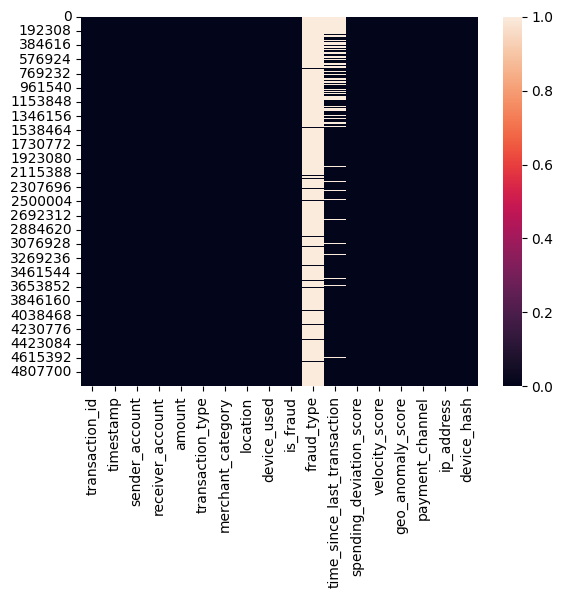

In [10]:
sns.heatmap(df.isna())

Handling Missing Values

Most columns do not contain missing values.  

However, the column **`time_since_last_transaction`** has approximately **18% missing values**, which is understandable since not every transaction has a previous transaction for the corresponding user.  

We will impute these missing values **only after splitting the data into training and test sets** to avoid introducing data leakage.  

In the meantime, we can create a **missing flag** — a new column indicating whether a value is missing — to preserve this information for the model.

In [5]:
# Creating missing flags for 'time_since_last_transaction'
df['time_since_last_transaction_missing'] = df['time_since_last_transaction'].isnull().astype(int)

In [12]:
dup_counts = df.apply(lambda col: col.duplicated(keep=False).sum()) # keep=False → marks all duplicates (including the first occurrence) as True.
print(dup_counts)

transaction_id                               0
timestamp                                    4
sender_account                         4980790
receiver_account                       4980744
amount                                 4977640
transaction_type                       5000000
merchant_category                      5000000
location                               5000000
device_used                            5000000
is_fraud                               5000000
fraud_type                             5000000
time_since_last_transaction             896513
spending_deviation_score               4999956
velocity_score                         5000000
geo_anomaly_score                      5000000
payment_channel                        5000000
ip_address                                5864
device_hash                            2132053
time_since_last_transaction_missing    5000000
dtype: int64


# Duplicate Checking – Interpretation

- **transaction_id:** 0 duplicates  
  - ✅ Unique identifier, perfect.

- **timestamp:** 4 duplicates  
  - Minor duplication, likely simultaneous transactions. Worth a brief check.

- **sender_account:** 4,980,790 duplicates  
- **receiver_account:** 4,980,744 duplicates  
  - Expected; accounts appear in multiple transactions. Useful for aggregated features (e.g., transaction counts, average amount).

- **amount:** 4,977,640 duplicates  
  - Many transactions share the same amount; normal for financial data.

- **transaction_type, merchant_category, location, device_used, is_fraud, fraud_type, velocity_score, payment_channel, geo_anomaly_score:** ~5,000,000 duplicates  
  - High duplication expected for categorical/constant columns; suitable for modeling and feature engineering.

- **time_since_last_transaction:** 896,513 duplicates  
  - Repeated time gaps are reasonable; can be used numerically after imputing missing values.

- **spending_deviation_score:** 4,999,956 duplicates  
  - Mostly repeated values; may require scaling/normalization.

- **ip_address:** 5,864 duplicates  
  - Some IPs used multiple times; can help detect shared or suspicious IPs.

- **device_hash:** 2,132,053 duplicates  
  - Shared across transactions; useful for identifying reused devices or fraud clusters.

**Summary:**  
- Only `transaction_id` is strictly unique; all others have expected duplicates.  
- Duplication in account, device, and categorical columns is normal and **key for feature engineering**.  
- No major data quality issues

In [13]:
fraud_counts = df['is_fraud'].value_counts()
fraud_counts 

is_fraud
False    4820447
True      179553
Name: count, dtype: int64

In [14]:
fraud_proportions = df['is_fraud'].value_counts(normalize=True)
fraud_proportions

is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64

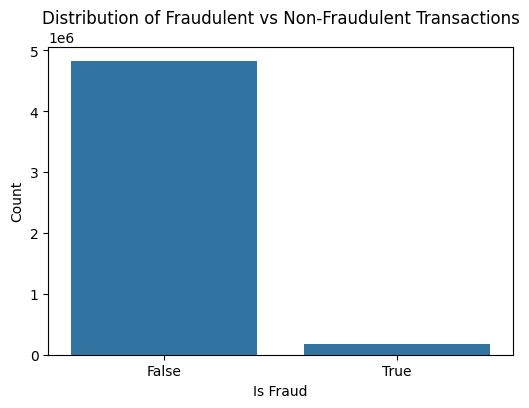

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()


We observe a significant class imbalance, which will require specific handling—such as oversampling or undersampling—in the **03_modeling.ipynb** notebook.

In the following, we convert the **`timestamp`** column from a string representation to a datetime format.

In [16]:
df.head()["timestamp"]

0    2023-08-22T09:22:43.516168
1    2023-08-04T01:58:02.606711
2    2023-05-12T11:39:33.742963
3    2023-10-10T06:04:43.195112
4    2023-09-24T08:09:02.700162
Name: timestamp, dtype: str

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')

In [18]:
bad_rows = df[df["timestamp"].isna()]
print(bad_rows)

        transaction_id timestamp sender_account receiver_account  amount  \
1891874       T1991874       NaT      ACC375307        ACC630432  195.84   
2833396       T2933396       NaT      ACC969484        ACC369350    4.55   
3214871       T3314871       NaT      ACC444490        ACC483161   28.20   

        transaction_type merchant_category   location device_used  is_fraud  \
1891874          deposit           grocery      Dubai         web     False   
2833396          payment            travel      Dubai         web     False   
3214871         transfer            online  Singapore         atm     False   

        fraud_type  time_since_last_transaction  spending_deviation_score  \
1891874        NaN                  4429.861012                      0.87   
2833396        NaN                  -352.835279                      1.20   
3214871        NaN                  6481.381027                     -1.32   

         velocity_score  geo_anomaly_score payment_channel      ip_ad

Next, we examine basic statistics and feature distributions.

In [19]:
# Summary statistics for numerical columns
df[['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score']].describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01
std,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01
min,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01
50%,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01
75%,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01
max,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00


### amount
- The mean (≈ 359) is much higher than the median (≈ 139), indicating a **strong right-skewed distribution**.
- Most transactions are small, but there are **significant high-value outliers** (max ≈ 3520).
- This reflects realistic transaction behavior and suggests potential usefulness for fraud detection.

### time_since_last_transaction
- Contains fewer observations (~4.1M vs ~5M), confirming **missing values (~18%)**.
- Extremely large standard deviation (~3576) and wide range (≈ -8778 to 8758) indicate **high variability and possible anomalies**.
- Negative values are suspicious and may reflect **data inconsistencies or engineered features (e.g., time differences with direction)**.
- Requires careful handling (missing values + potential cleaning or transformation).

### spending_deviation_score
- Mean ≈ 0 and median = 0 → centered around zero.
- Symmetric distribution (25% ≈ -0.68, 75% ≈ 0.67).
- Likely a **standardized feature (z-score)** representing deviation from normal spending behavior.
- Well-scaled and highly suitable for modeling.

### velocity_score
- Range: 1–20, with mean ≈ 10.5 and median ≈ 11.
- Fairly symmetric distribution with moderate spread.
- Appears to be a **bounded engineered feature**, already normalized and stable.

### geo_anomaly_score
- Range: 0–1, mean ≈ 0.5, evenly spaced quartiles.
- Indicates a **uniform distribution**, typical for normalized anomaly scores.
- Likely encodes geographic risk or unusual location behavior.

### Summary
- `amount` → skewed with outliers → may benefit from transformation (e.g., log).  
- `time_since_last_transaction` → problematic (missing + extreme + negative values) → requires careful preprocessing.  
- `spending_deviation_score`, `velocity_score`, `geo_anomaly_score` → well-engineered, scaled, and model-ready.

In [20]:
# Value counts for categorical columns
merchant_counts =df["merchant_category"].value_counts()
device_used_counts = df["device_used"].value_counts()
transaction_type_counts = df['transaction_type'].value_counts()
payment_channel_counts = df['payment_channel'].value_counts()

print("Value counts for 'merchant_category': ")
print(merchant_counts)  
print("\nValue counts for 'device_used': ")
print(device_used_counts)   
print("\nValue counts for 'transaction_type': ")
print(transaction_type_counts)

Value counts for 'merchant_category': 
merchant_category
retail           626319
travel           625656
restaurant       625483
entertainment    625332
grocery          624954
other            624589
utilities        624086
online           623581
Name: count, dtype: int64

Value counts for 'device_used': 
device_used
mobile    1251131
web       1250071
atm       1249640
pos       1249158
Name: count, dtype: int64

Value counts for 'transaction_type': 
transaction_type
deposit       1250593
payment       1250438
transfer      1250334
withdrawal    1248635
Name: count, dtype: int64


### merchant_category
- All categories have very similar frequencies (~624k–626k).
- This indicates a **balanced distribution across categories**, with no dominant class.
- No immediate need for grouping or handling rare categories.

### device_used
- The distribution is nearly perfectly balanced across all device types (~1.25M each).
- This suggests no bias toward a specific device in the dataset.
- Useful for modeling without additional rebalancing.

### transaction_type
- All transaction types occur with almost identical frequency (~1.25M each).
- Indicates a **uniform distribution**, which simplifies modeling and reduces bias risk.

### Summary
- All categorical features are **well-balanced**.
- No need for handling class imbalance within these features.
- Suitable for standard encoding techniques (e.g., one-hot encoding).

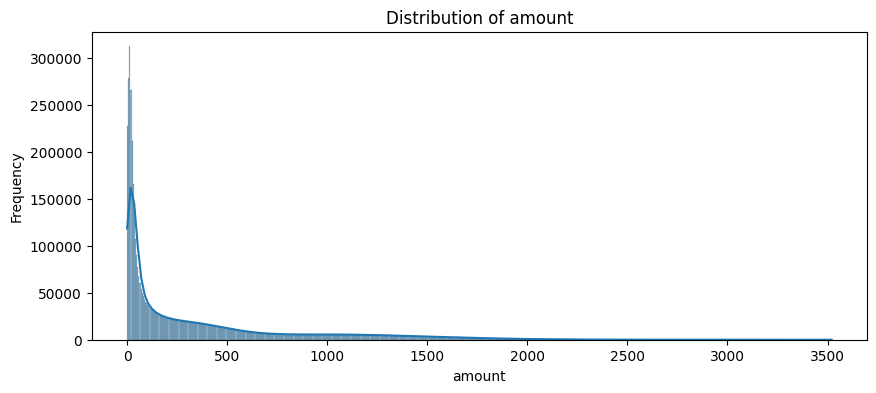

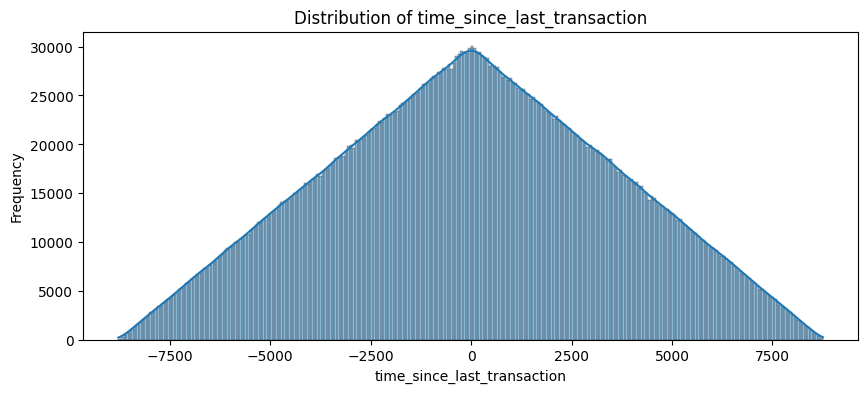

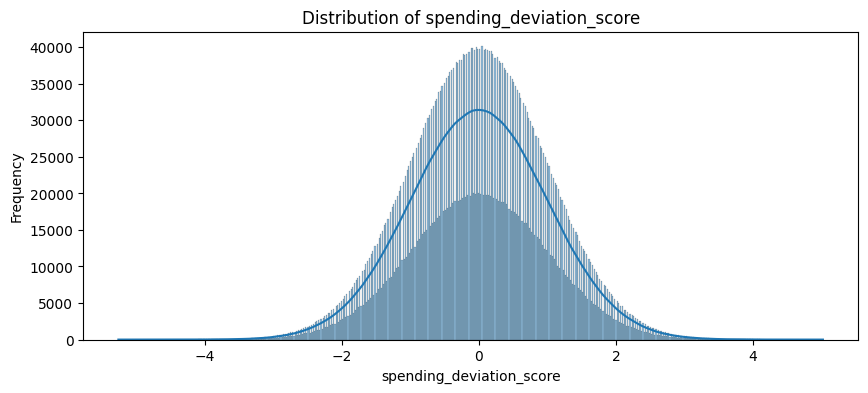

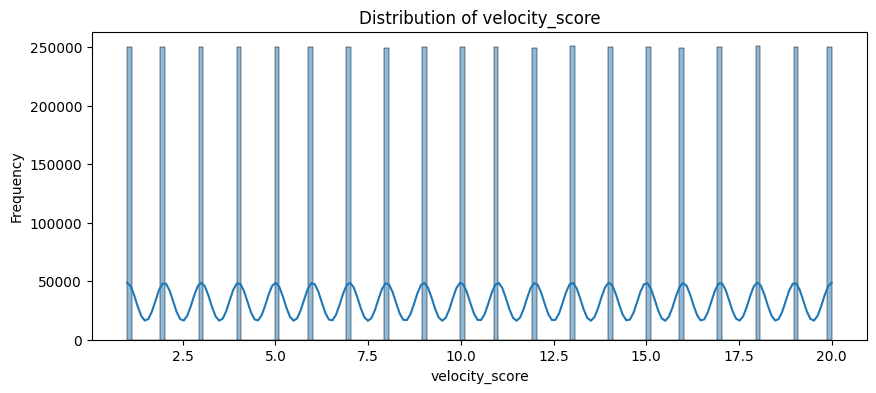

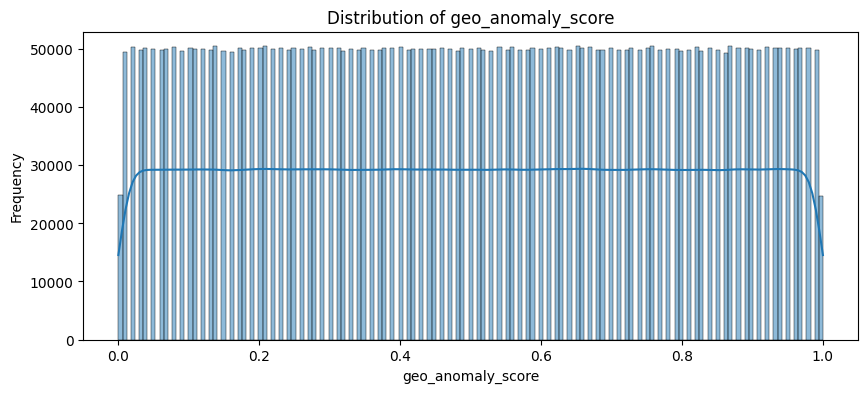

In [21]:
# feature distribution of numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score']
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

The distributions of **`time_since_last_transaction`**, **`spending_deviation_score`**, **`velocity_score`**, and **`geo_anomaly_score`** indicate that these features are already well-engineered. The only transformation required for these features will likely be scaling for certain models.  

However, the distribution of the **`amount`** column confirms our initial suspicion that it is heavily right-skewed. Therefore, we will likely need to apply a log transformation to this column later.

Next, we save the dataset in **Parquet format** using the **pyarrow** engine.  

The only modification from the raw, initial version is the conversion of the **`timestamp`** column to a datetime datatype.

In [11]:
# Saving the DataFrame in Parquet format 
df.to_parquet('../data/interim/df_dtypes_fixed.parquet', engine='fastparquet', compression='snappy')
